Importing the libaries


In [1]:
import sys
import os

sys.path.append(os.path.abspath("src"))

import gc
import textwrap
import re
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import DataLoader, random_split
from transformers import BertTokenizer

import src.train as train_module
from src.model import *
from src.utils import *
from src.train import config
import src.train as train_module

c:\Users\Kishan Prasad Jasiwa\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
os.makedirs("results/baseline", exist_ok=True)
print("✅ results/baseline folder ready")

✅ results/baseline folder ready


Config

In [3]:
flags = config["flags"]

USE_FRAME_AWARE_GROUNDING = flags["use_frame_aware_grounding"]
USE_CONTRASTIVE_ROI = flags["use_contrastive_roi"]
USE_ENTITY_POOLING = flags["use_entity_pooling"]
USE_COT_TEXT = flags["use_cot_text"]

CONTRASTIVE_TAU = config["loss"]["contrastive_tau"]

Setup Device

In [4]:
torch.cuda.empty_cache()
gc.collect()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


Load Dataset

In [5]:
train_dataset = get_storyreasoning_dataset(split="train")
test_dataset = get_storyreasoning_dataset(split="test")

print(train_dataset)
print(train_dataset[0])

Dataset({
    features: ['story_id', 'images', 'frame_count', 'chain_of_thought', 'story'],
    num_rows: 3552
})
{'story_id': '3920', 'images': [<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=575x240 at 0x23C67F28880>, <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=575x240 at 0x23C67F2BD00>, <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=575x240 at 0x23C67F2BCD0>, <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=575x240 at 0x23C67F2BCA0>, <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=575x240 at 0x23C67F2B250>, <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=575x240 at 0x23C67F2B6A0>, <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=575x240 at 0x23C67F2B640>, <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=575x240 at 0x23C67F2BDF0>, <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=575x240 at 0x23C67F2BC10>, <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=575x240 at 0x23C67F2BF10>, <PIL.JpegImagePlugin.JpegImageFile

Tokenizer

In [6]:
tokenizer = BertTokenizer.from_pretrained(
    "google-bert/bert-base-uncased"
)

Dataset Preparation

In [7]:
sp_train_dataset = SequencePredictionDataset(train_dataset, tokenizer)
sp_test_dataset = SequencePredictionDataset(test_dataset, tokenizer)

Train/Validation Split

In [8]:
train_size = int(0.8 * len(sp_train_dataset))
val_size = len(sp_train_dataset) - train_size

train_subset, val_subset = random_split(
    sp_train_dataset,
    [train_size, val_size]
)

Dataloaders

In [9]:
train_dataloader = DataLoader(train_subset, batch_size=8, shuffle=True)
val_dataloader = DataLoader(val_subset, batch_size=4, shuffle=True)
test_dataloader = DataLoader(sp_test_dataset, batch_size=4, shuffle=False)

Model Setup

In [10]:
encoder = EncoderLSTM(tokenizer.vocab_size, 16, 16)
decoder = DecoderLSTM(tokenizer.vocab_size, 16, 16)

text_autoencoder = Seq2SeqLSTM(encoder, decoder)

text_autoencoder, _, _, _ = load_checkpoint_from_drive(
    text_autoencoder,
    None,
    filename="text_autoencoder.pth"
)

# Freeze text model
for p in text_autoencoder.parameters():
    p.requires_grad = False


visual_autoencoder = VisualAutoencoder(latent_dim=16)
visual_autoencoder.apply(train_module.init_weights)

sequence_predictor = SequencePredictor(
    visual_autoencoder,
    text_autoencoder,
    latent_dim=16,
    gru_hidden_dim=16
).to(device)

optimizer = torch.optim.Adam(sequence_predictor.parameters(), lr=1e-4)

c:\Users\Kishan Prasad Jasiwa\Desktop\Dnnls_Final_Project\dnnls_final_project\src\utils.py:51: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(full_pat

Checkpoint loaded from ./checkpoints\text_autoencoder.pth (epoch 15)


Validation Function

In [11]:
def validation_fn(model, data_loader, device):
    model.eval()

    with torch.no_grad():
        frames, descriptions, image_target, text_target, roi1, roi2, roi_valid, roi_frame, ent_id = next(iter(data_loader))

        frames = frames.to(device)
        descriptions = descriptions.to(device)
        image_target = image_target.to(device)

        pred_img, context_img, _, _, _, _, _ = model(
            frames, descriptions, text_target.to(device)
        )

        fig, ax = plt.subplots(2, 6, figsize=(20, 5))

        for i in range(4):
            show_image(ax[0, i], frames[0, i].cpu())
            ax[0, i].axis("off")

            txt = tokenizer.decode(descriptions[0, i], skip_special_tokens=True)
            ax[1, i].text(0.5, 0.5, textwrap.fill(txt, 40))
            ax[1, i].axis("off")

        show_image(ax[0, 4], image_target[0].cpu())
        ax[0, 4].axis("off")

        show_image(ax[0, 5], context_img[0].cpu())
        ax[0, 5].axis("off")

        plt.tight_layout()
        plt.show()

Training

Epoch [1/10] Loss: 4.4299 (im=0.272, ctx=0.033, txt=4.151)


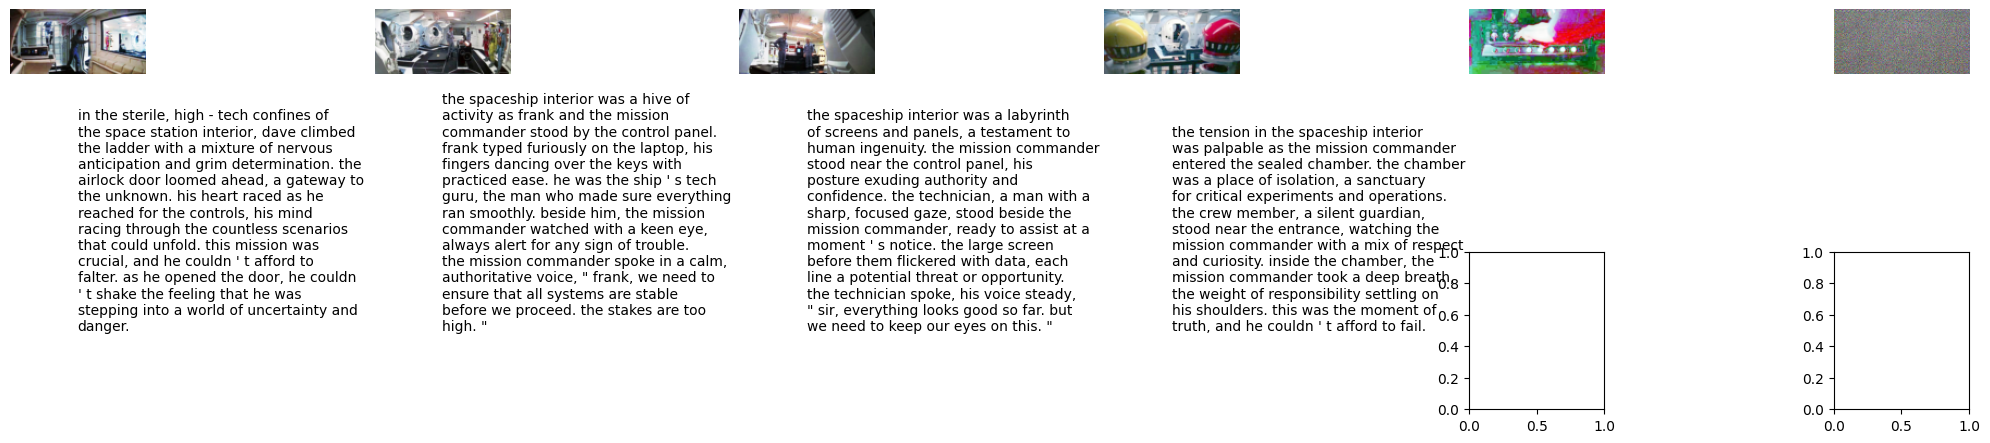

Epoch [2/10] Loss: 4.3584 (im=0.260, ctx=0.030, txt=3.879)


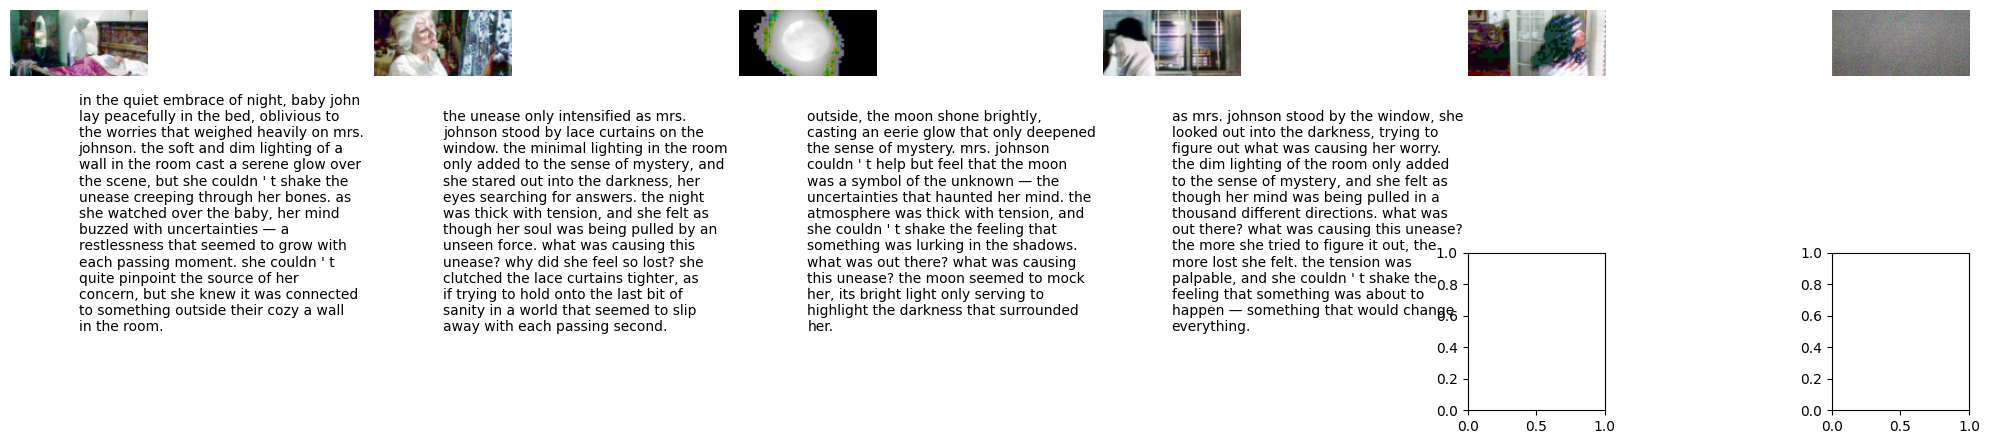

Epoch [3/10] Loss: 4.3362 (im=0.237, ctx=0.014, txt=3.465)


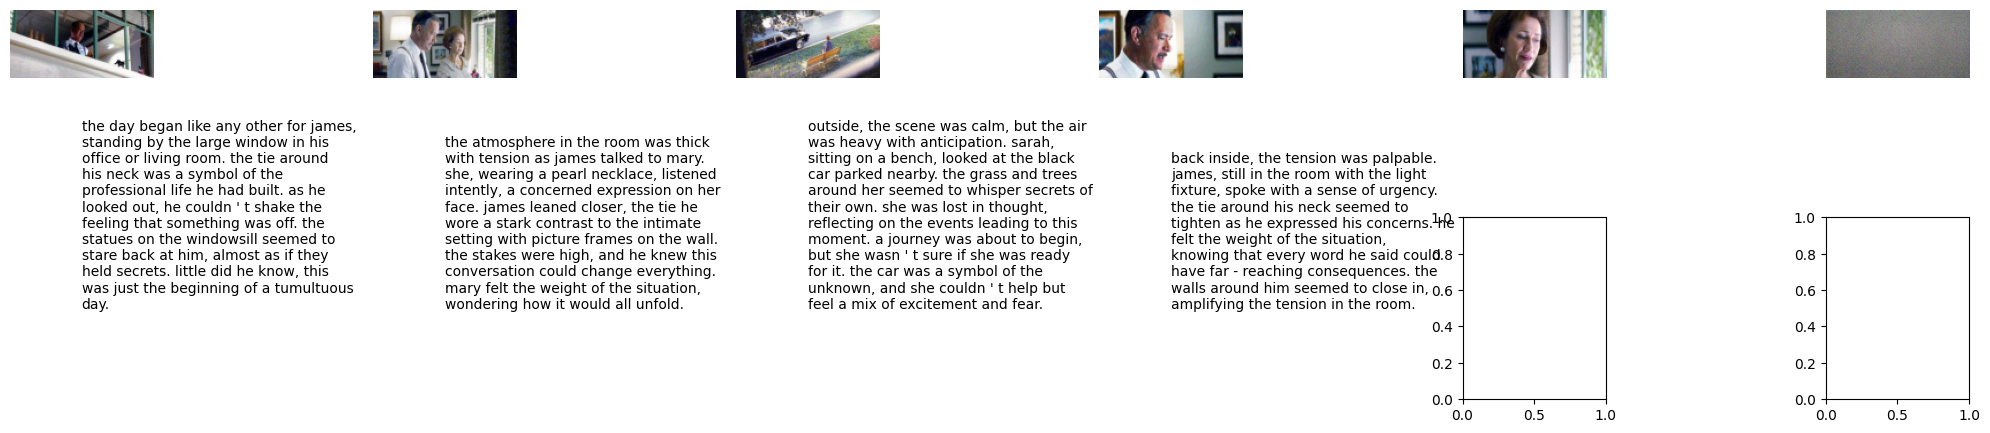

Epoch [4/10] Loss: 4.3305 (im=0.237, ctx=0.019, txt=3.212)


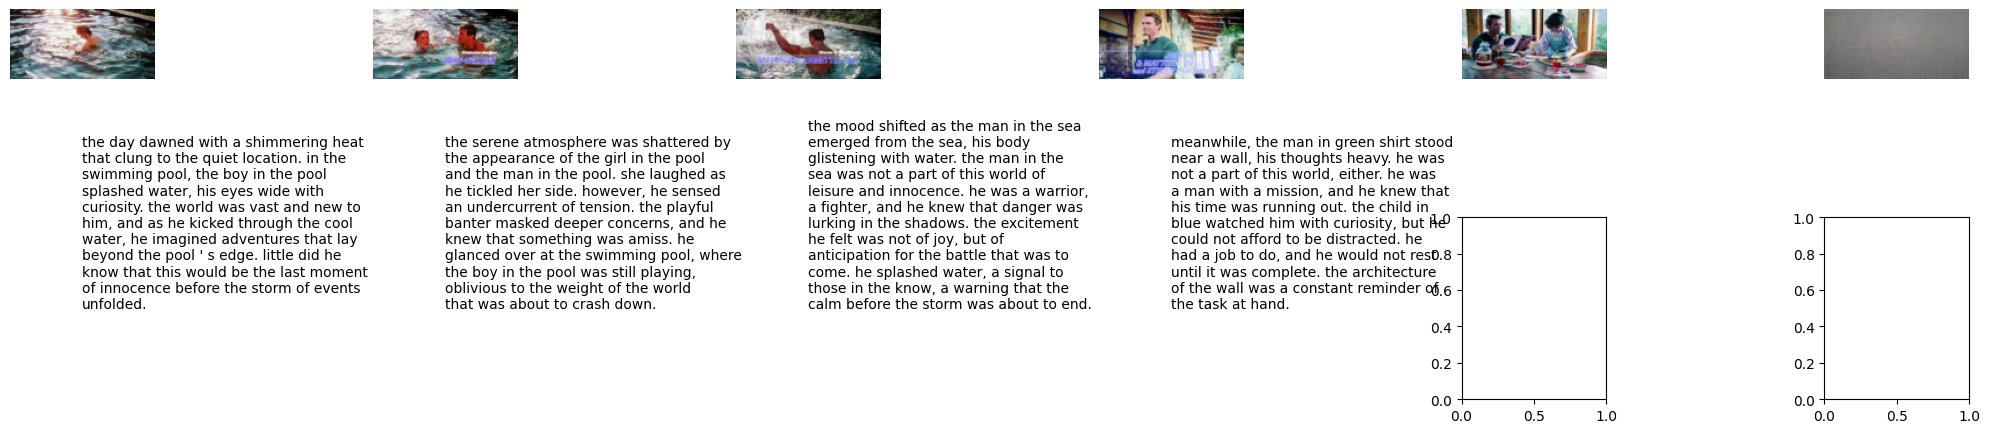

Epoch [5/10] Loss: 4.3262 (im=0.235, ctx=0.036, txt=4.056)


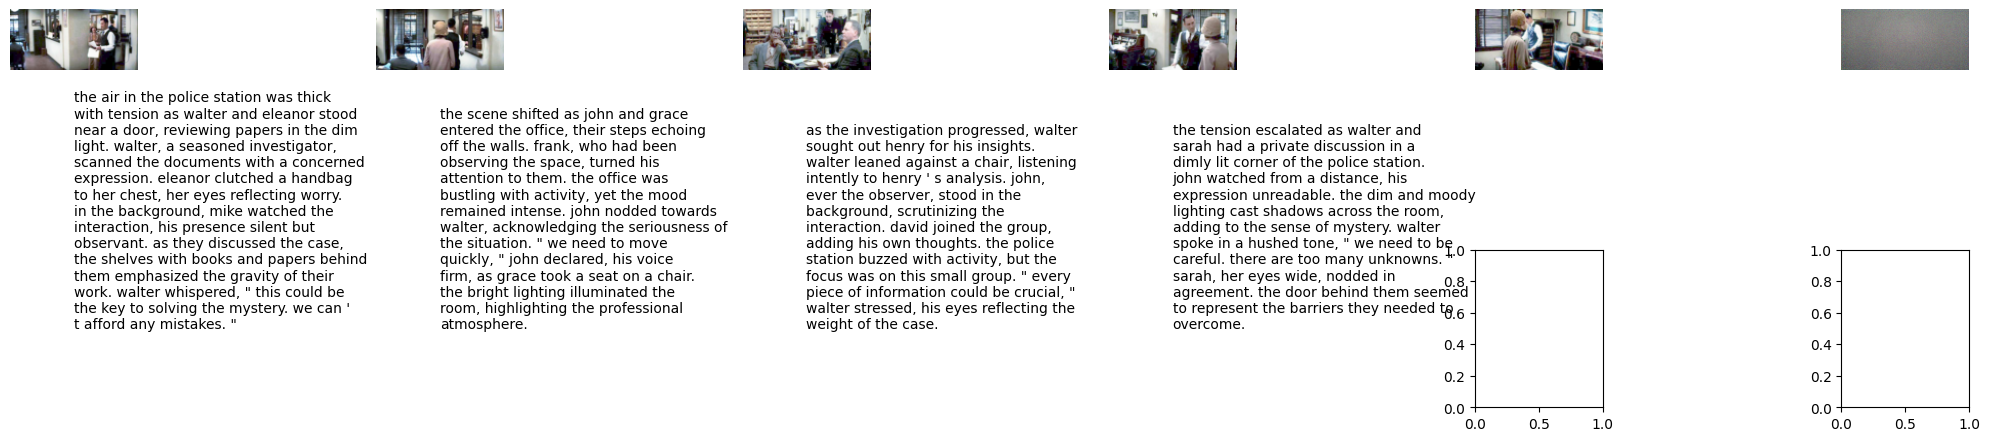

Epoch [6/10] Loss: 4.3246 (im=0.235, ctx=0.017, txt=4.100)


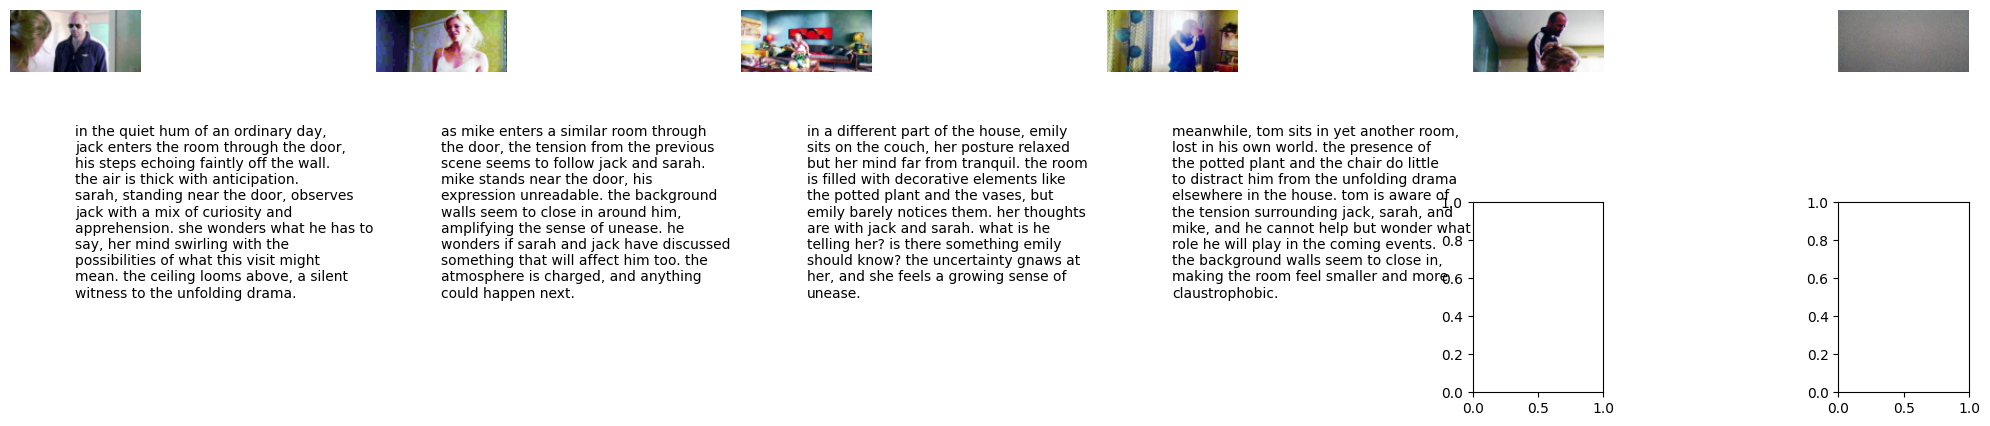

Epoch [7/10] Loss: 4.3205 (im=0.230, ctx=0.026, txt=4.097)


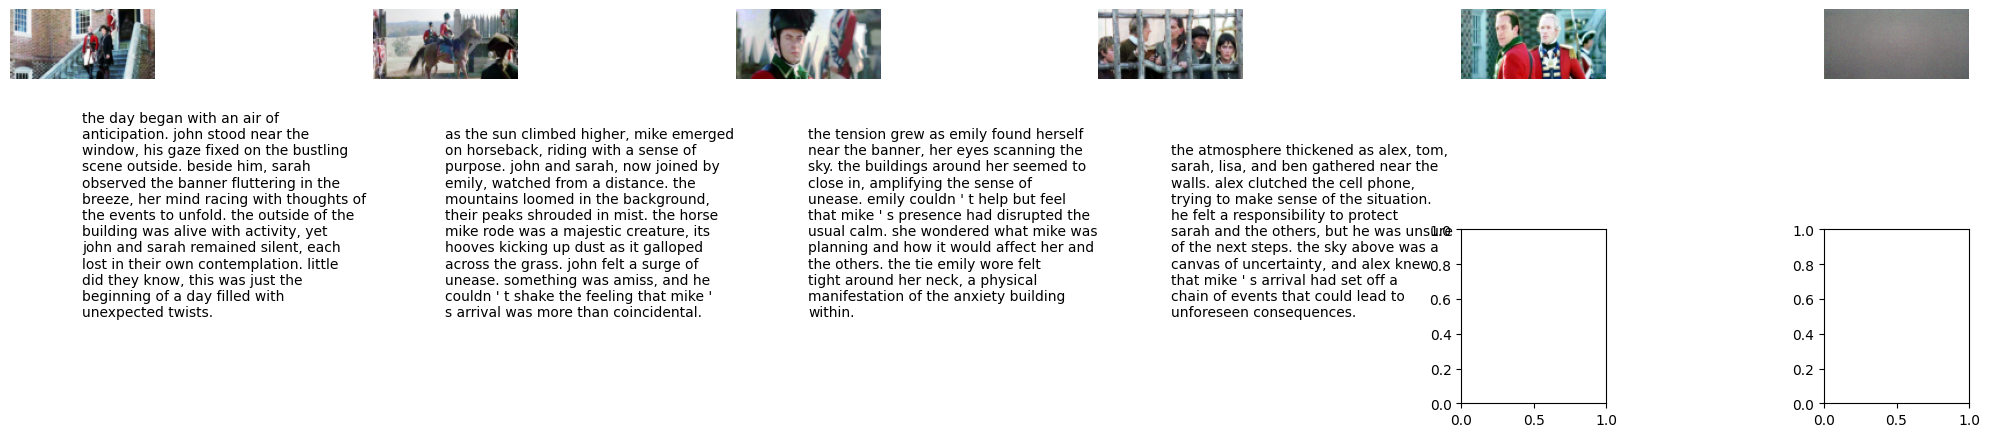

Epoch [8/10] Loss: 4.3193 (im=0.217, ctx=0.020, txt=4.489)


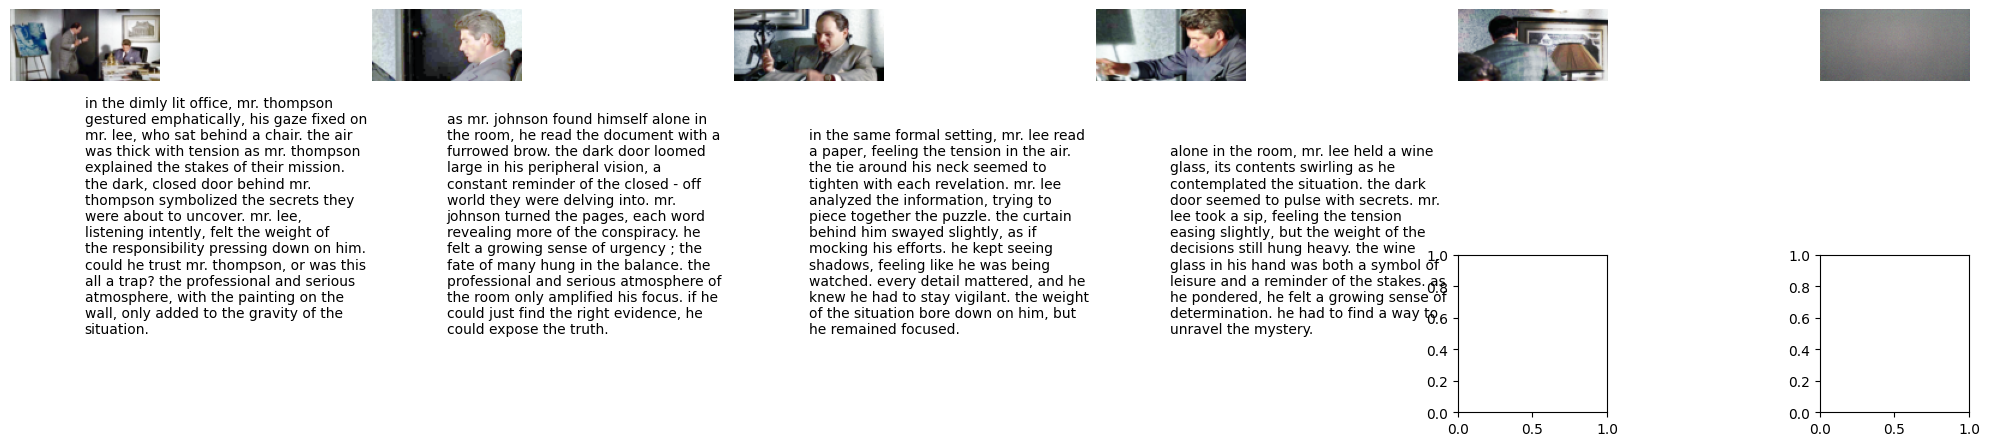

Epoch [9/10] Loss: 4.3150 (im=0.232, ctx=0.028, txt=3.530)


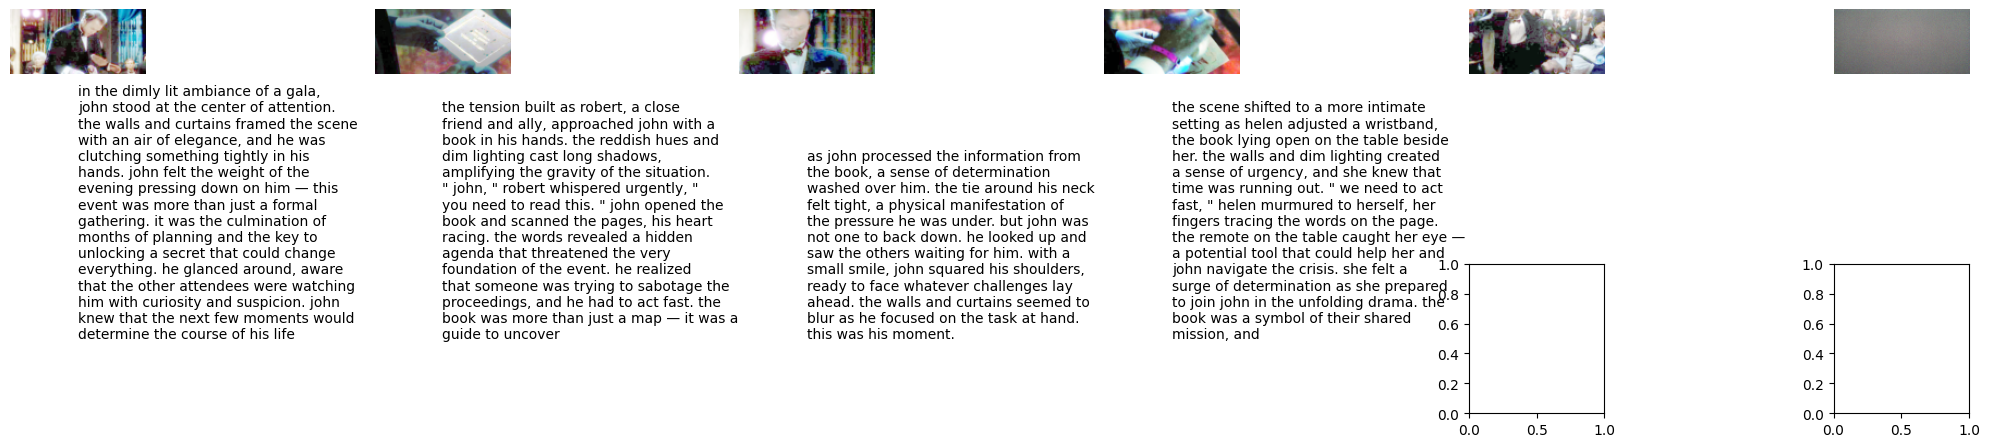

Epoch [10/10] Loss: 4.3157 (im=0.212, ctx=0.032, txt=4.243)


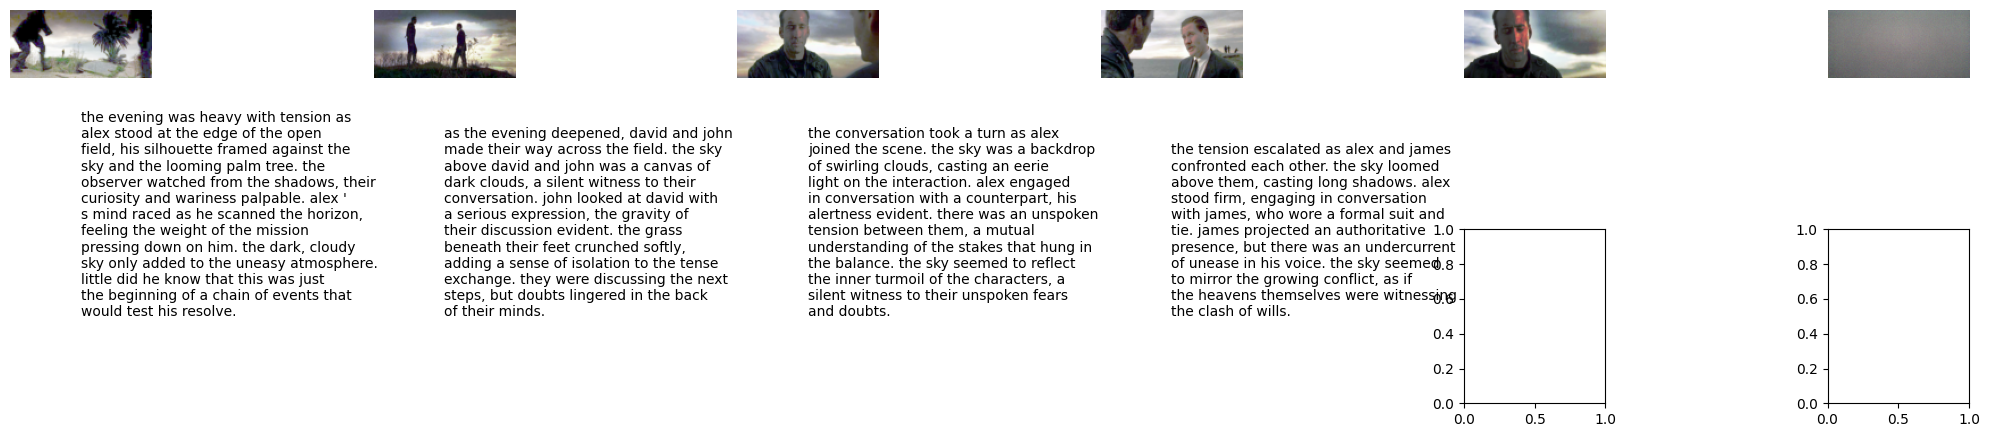

In [12]:
N_EPOCHS = 10

losses = train_module.train_sequence_predictor(
    sequence_predictor,
    train_dataloader,
    val_dataloader,
    optimizer,
    tokenizer,
    device,
    N_EPOCHS,
    validation_fn=validation_fn
)

Saving Training Log (Baseline Experiment)

In [13]:
log_path ="results/baseline/training_log.txt"

with open(log_path, "w") as f:
    for i, loss in enumerate(losses):
        line = f"Epoch {i+1} Loss: {loss: 4f}"
        print(line)
        f.write(line + "\n")

print("Training log saved")

Epoch 1 Loss:  4.429876
Epoch 2 Loss:  4.358434
Epoch 3 Loss:  4.336230
Epoch 4 Loss:  4.330526
Epoch 5 Loss:  4.326200
Epoch 6 Loss:  4.324603
Epoch 7 Loss:  4.320497
Epoch 8 Loss:  4.319265
Epoch 9 Loss:  4.315021
Epoch 10 Loss:  4.315667
Training log saved


Validation Run

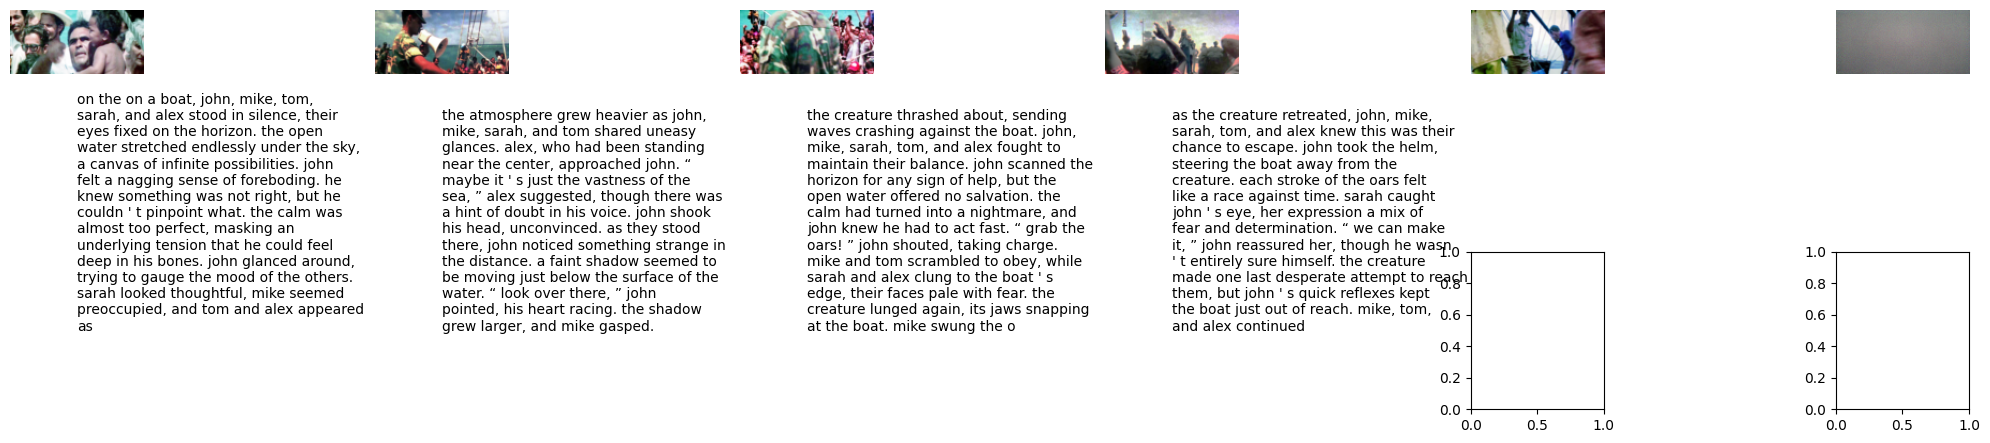

SequencePredictor(
  (image_encoder): VisualEncoder(
    (context_backbone): Backbone(
      (encoder_conv): Sequential(
        (0): Conv2d(3, 16, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3))
        (1): GroupNorm(8, 16, eps=1e-05, affine=True)
        (2): LeakyReLU(negative_slope=0.1)
        (3): Conv2d(16, 32, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
        (4): GroupNorm(8, 32, eps=1e-05, affine=True)
        (5): LeakyReLU(negative_slope=0.1)
        (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
        (7): GroupNorm(8, 64, eps=1e-05, affine=True)
        (8): LeakyReLU(negative_slope=0.1)
      )
      (fc1): Sequential(
        (0): Linear(in_features=8192, out_features=16, bias=True)
        (1): ReLU()
      )
    )
    (content_backbone): Backbone(
      (encoder_conv): Sequential(
        (0): Conv2d(3, 16, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3))
        (1): GroupNorm(8, 16, eps=1e-05, affine=True)
        (2): LeakyR

In [14]:
validation_fn(sequence_predictor, val_dataloader, device)
sequence_predictor.eval()

Inference

In [20]:
sample = next(iter(val_dataloader))

frames, descriptions, image_target, text_target, *_ = sample

frames = frames.to(device)
descriptions = descriptions.to(device)
text_target = text_target.to(device)

with torch.no_grad():
    pred_img, _, pred_text_logits, *_ = sequence_predictor(
        frames, descriptions, text_target
    )

Decode Predictions

In [21]:
pred_tokens = pred_text_logits.argmax(dim=-1)

pred_sentences = [
    tokenizer.decode(seq.cpu().numpy(), skip_special_tokens=True)
    for seq in pred_tokens
]

true_sentences = [
    tokenizer.decode(seq.cpu().numpy(), skip_special_tokens=True)
    for seq in text_target.squeeze(1)
]

print("\n🔹 Sample Predictions:\n")

for i in range(min(3, len(pred_sentences))):
    print(f"Predicted: {pred_sentences[i]}")
    print(f"Actual   : {true_sentences[i]}")
    print("-" * 50)


🔹 Sample Predictions:

Predicted: the tension shifted to he stood the, the the stood near the room, the expressions a sense of unease. the. the, the the silent, a to sense of the. the situation. the, with, his he, his need s intently a the moment. the ' s intently a, the we,, his mind.foldingring. the room was the was to close the tension. the shoulders. felt the,, s mind, and a sense of unease. on lighting lighting lighting lighting lighting lightingllllllllllllll
Actual   : the scene shifted as sarah, emily, and alex stood near the door, their expressions a mix of hope and anticipation. emily, holding a baby, added a layer of vulnerability to the group. sarah spoke softly, " jack, we ' re all in this together. you ' re not alone. " alex nodded, his resolve unwavering. the wall and wall seemed to reflect the unity of their purpose. jack, hearing sarah ' s words, felt a surge of strength.
--------------------------------------------------
Predicted: the as room, the, the, the, the nea

Image Output Visualization

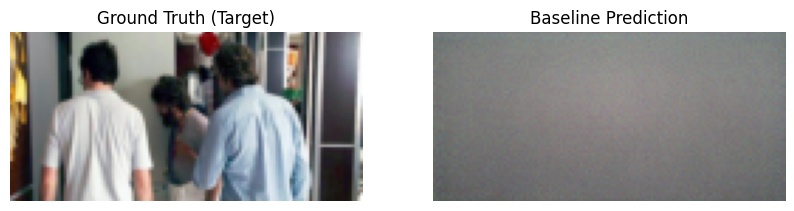

Saved : ('results/baseline/predictionexample.png', {'results/baseline/visualcomparision.png'})


In [26]:
pred_path = "results/baseline/predictionexample.png"
gt_path = "results/baseline/groundtruth.png"
comparision_path= "results/baseline/visualcomparision.png"

# Prediction Image
plt.imsave(pred_path,pred_img[0].cpu().permute(1, 2, 0).numpy())

# Ground Truth Image
plt.imsave(gt_path,image_target[0].cpu().permute(1,2,0).numpy())

# Side by Side comparision figure
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(image_target[0].cpu().permute(1,2,0))
plt.title('Ground Truth (Target)')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(pred_img[0].cpu().permute(1,2,0))
plt.title('Baseline Prediction')
plt.axis('off')

plt.savefig(comparision_path)
plt.show()

print(f'Saved : {pred_path,{gt_path} and {comparision_path}}')

Loss curve

In [ ]:
plot_path = "results/baseline/losscurve.png"

plt.figure(figsize=(8,5))
plt.plot(losses, label ='Baseline Training Loss', color= 'blue', linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline: Loss Curve")
plt.legend()
plt.grid(True)

# Save for baseline results
plt.savefig(plot_path)
plt.show()
plt.close()

print(f"Loss Curve Saved: {plot_path}")

Loss Curve Saved


In [19]:
import torch
print(torch.cuda.is_available())


True


Metrics Calculation & Table Saving

In [33]:
from torchmetrics.text.bleu import BLEUScore

# Calculate BLEU-4 Score
bleu_metric = BLEUScore(n_gram=4)
reference = [[s] for s in true_sentences]
baseline_bleu_val = bleu_metric(pred_sentences,reference).item()

# Results 
print ("\n" + "="*50)
print("Baseline Results")
print("="*50)
print(f'Final Training Loss: {losses[-1]:.4f}')
print(f"BLEU-4 Accuracy: {baseline_bleu_val:.4f}")
print("="*50 +"\n")

# Save to metrics.txt
metrics_path = "results/baseline/metrics.txt"
with open(metrics_path, "w") as f:
    f.write("Baseline\n")
    f.write("=" *40 + "\n")
    f.write(f"{'Metric':<25} | {'Value':<10}\n")
    f.write("-" * 40 + "\n")
    f.write(f"{'Final Training Loss':<25} | {losses[-1]:.4f}\n")
    f.write(f"{'BLEU-4 Accuracy':<25} | {baseline_bleu_val:.4f}\n")
    f.write(f"{'Epochs Completed':<25} | {len(losses)}\n")

print(f" Baseline metrics table saved : {metrics_path}")


Baseline Results
Final Training Loss: 4.3157
BLEU-4 Accuracy: 0.0000

 Baseline metrics table saved : results/baseline/metrics.txt
